In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Atractors estranys i exponent de Lyapunov

Hem vist per ara punts fixos atractors i òrbites periòdiques atractores. És possible que hi hagi altres conjunts atractors?

**Definició.** Un conjunt $C$ és un atractor de $x_{n+1}=f(x_n)$ si:

a) $C$ és acotat.

b) $f(C)=C$, és a dir, $C$ és invariant per $f$.

c) $\forall U\in\mathbb{R}$ entorn obert de $C$ existeix un obert $V\subset U$ que conté $C$ tal que $\forall x\in V$, $O_{+}(x)\subset U$, és a dir, $C$ és estable per $f$.

d) $\exists U\subset \mathbb{R}$ entorn obert de $C$ tal que $\forall x\in U$, $\lim_{n\rightarrow\infty} d(f^n(x),C)=0$ on $d(x,C)=\min\{\|x-\bar{x}\| : \bar{x}\in C\}$.

e) Si $C'\subset C$ i $f(C')=C'$ aleshores $C'$ no és estable.


**Definició.** La conca d'atracció d'un atractor $C$ és la unió de tots els oberts $U$ que satisfan la condició (d).

En aquest punt és natural preguntar-se si existeixen atractors que no siguin ni punts fixos ni òrbites periòdiques.

**Definició.** Sigui $f:\mathbb{R}\rightarrow\mathbb{R}$. Donat $x\in\mathbb{R}$ es defineix el multiplicador de Lyapunov de la semiòrbita positiva de $x$ com $$\Lambda(x) = \lim_{n\rightarrow\infty}|(f^n)'(x)|^{1/n},$$ en cas que existeixi.

El multiplicador de Lyapunov dóna informació sobre com es comporta la distància entre els punts $f^n(x)$ i $f^n(\tilde{x})$ on $\tilde{x}\approx x$ a mesura que $n$ es fa gran. En concret tenim $$|f^n(x)-f^n(\tilde{x})|\approx \Lambda(x)^n|x-\tilde{x}|$$ sempre que $\tilde{x}$ sigui prou proper a $x$ i $n$ sigui prou gran. Aquest fet queda justificat pel següent:
$$|f^n(x)-f^n(\tilde{x})| = |x-\tilde{x}|\left|\frac{f^n(x)-f^n(\tilde{x})}{x-\tilde{x}} \right| \approx |x-\tilde{x}||(f^n)'(x)|\approx |x-\tilde{x}|\Lambda(x)^n.$$ De fet, com més gran sigui $n$, més propers han d'estar $x$ i $\tilde{x}$ ja que les derivades de $f^n$ tendeixen a fer-se cada cop més grans.

El multiplicador de Lyapunov dóna una mesura sobre si les òrbites de punts propers tendeixen a convergir o divergir.

- Si $\Lambda(x)>1$, $O_+(x)$ i $O_+(\tilde{x})$ tendeixen a separar-se. En aquesta situació diem que el sistema és *sensible respecte de les condicions inicials* en aquesta regió de l'espai.
- Si $\Lambda(x)<1$, $O_+(x)$ i $O_-(\tilde{x})$ tendeixen a apropar-se.

**Definició**. L'exponent de Lyapunov es defineix com $\lambda(x)=\ln\Lambda(x)$.

Un mètode per calcular $\lambda(x)$ és el següent: definim $x_n=f^n(x_0)$ amb $x_0=x$. Per la regla de la cadena,
$$|(f^n)'(x)|=|f'(f^{n-1}(x_0))\cdot f'(f^{n-2}(x_0))\cdots f'(f(x_0))\cdot f'(x_0)| = |f'(x_{n-1})\cdot f'(x_{n-2})\cdots f'(x_1)\cdot f'(x_0)|.$$
Llavors, $$\lambda(x) = \ln\Lambda(x) = \ln \lim_{n\rightarrow\infty} |(f^n)'(x)|^{1/n} = \lim_{n\rightarrow\infty} \frac{1}{n}\ln|(f^n)'(x)|=\lim_{n\rightarrow\infty}\frac{1}{n}\sum_{j=0}^{n-1}\ln|f'(x_j)|.$$
Així, per tal de calcular, de manera aproximada, l'exponent de Lyapunov de la semiòrbita positiva de $x$, només cal conèixer la derivada de $f$ en els punts de l'òrbita $O_+(x)$.

**Observació.** De fet, l'exponent de Lyapunov només té en compte el comportament asimptòtic. Per tant, per tenir una millor aproximació, és oportú calcular l'aproximació numèrica a partir d'un punt de l'òrbita $O_+(x)$ prou endavant. D'aquesta manera s'elimina possibles comportaments transitoris.

**Lemma.** Sigui $g:\mathbb{R}\rightarrow\mathbb{R}$ contínua i $x_n\rightarrow x$ quan $n\rightarrow\infty$. Aleshores $$\lim_{n\rightarrow\infty}\sum_{j=0}^{n-1}g(x_n)=g(x).$$.

**Proposició.** Sigui $f\in\mathcal{C}^1$ i suposem que $x\in\mathbb{R}$ convergeix a un punt fix atractor $x^*$ amb $|f'(x^*)|<1$. Aleshores $\lambda(x)=\ln|f'(x^*)|<0$.

*Prova.* Definim $g(x):=\ln|f'(x)|$. Com que $g$ és contínua i $x_n=f^n(x)\rightarrow x^*$, pel Lemma anterior tenim $$\lambda(x)=\lim_{n\rightarrow\infty}\frac{1}{n}\sum_{j=0}^{n-1}\ln|f'(x_j)| = \ln|f'(x^*)|.$$

## Exemple: l'aplicació tenda

L'aplicació tenda és el sistema dinàmic discret donat per la iteració de la funció 
$$T(x) = \begin{cases} 2x & \text{si } x < \frac{1}{2} \\
2 - 2x & \text{si } x \ge \frac{1}{2}.\end{cases}$$

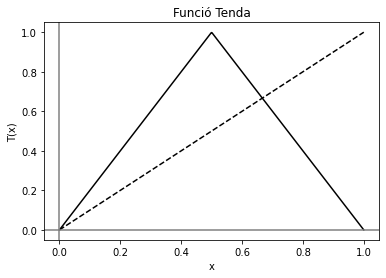

In [8]:
def f(x):
    if x < 0.5:
        return 2*x
    else:
        return 2-2*x

x_vals = np.linspace(0, 1, 500)
y_vals = [f(x) for x in x_vals]

plt.plot(x_vals, y_vals,'k-')
plt.plot(x_vals, x_vals, 'k--')
plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.xlabel("x")
plt.ylabel("T(x)")
plt.title("Funció Tenda")

plt.show()

Les òrbites fora de $[0,1]$ són divergents, mentre que l'interval $[0,1]$ és invariant per $T$, és a dir, $T([0,1])=[0,1]$. Observem a més que $|f'(x)|=2$ per a tot punt $x\in[0,1]\setminus\{1/2\}$. Així doncs, qualsevol punt fix u òrbita periòdica és repulsora. Si $x\in(0,1)$, 
$$\lambda(x) = \lim_{n\rightarrow\infty}\frac{1}{n}\sum_{j=0}^{n-1}\ln|f'(x_j)| = \lim_{n\rightarrow\infty}\frac{1}{n}\sum_{j=0}^{n-1}\ln 2 = \ln 2>1.$$

Per tant en l'interval $(0,1)$ ha d'haver-hi "quelcom" atractor. D'aquest objecte en diem *atractor estrany*. Observem que en el càlcul previ cal treure les preimatges de $1/2$ ja que $f$ no és derivable a $x=1/2$. Això, però, es tracta d'un conjunt numerable de mesura zero.

## Exemple: l'aplicació logística

Per l'aplicació logística (i, en general) l'exponent de Lyapunov no es pot calcular explícitament. El següent mostra el càlcul aproximat de l'exponent de Lyapunov d'una òrbita a l'atzar i una representació d'aquesta òrbita.

Exponent de Lyapunov aproximat: 0.10372631347642587


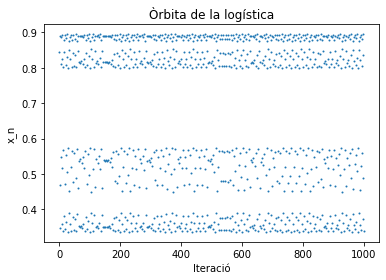

In [12]:
def logistica(x,lam):
    return lam*x*(1-x)

def dif_logistica(x,lam):
    return lam*(1-2*x)

# Paràmetres
x0 = np.random.rand()    # condició inicial aleatòria en (0,1)
N = 1000                  # nombre d'iteracions
lam = 3.58                # paràmetre lam de la logística (entre 3 i 4)

# Inicialització
x = x0
lyap_sum = 0

for i in range(N):
    lyap_sum += np.log(abs(dif_logistica(x,lam)))
    x = logistica(x,lam)

lyap = lyap_sum/N
print("Exponent de Lyapunov aproximat:", lyap)

orbit = []
for i in range(N):
    x = logistica(x,lam)
    orbit.append(x)

plt.plot(orbit, '.', markersize=2)
plt.xlabel("Iteració")
plt.ylabel("x_n")
plt.title("Òrbita de la logística")
plt.show()


A continuació es mostra el valor de l'exponent de Lyapunov d'una òrbita agafada a l'atzar per a cada valor del paràmetre $\lambda\in(0,1)$. Observem que aquest valor es fa positiu prop de $\lambda=3.58$.

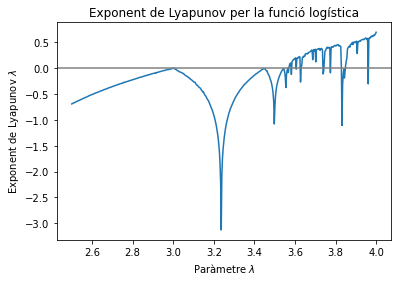

In [19]:
lam_values = np.linspace(2.5, 4.0, 500)
lyap_values = []

for lam in lam_values:
    x = np.random.rand()
    lyap_sum = 0
    for i in range(1000):
        lyap_sum += np.log(abs(dif_logistica(x,lam)))
        x = logistica(x,lam)
    lyap_values.append(lyap_sum/1000)

plt.plot(lam_values, lyap_values)
plt.axhline(0, color='grey')
plt.xlabel('Paràmetre $\lambda$')
plt.ylabel('Exponent de Lyapunov $\lambda$')
plt.title('Exponent de Lyapunov per la funció logística')
plt.show()